# 1. Problem Statement :
objective is to predict whether a person is an Introvert or Extrovert, given their social behavior and personality traits.

Competition page : https://www.kaggle.com/competitions/playground-series-s5e7

# 2. Understanding The Data.

|Feature|Meaning|
|-------|-------|
|id|Identifier of each Person|
|Time_spent_Alone|Hours spent alone daily (0–11).|
|Stage_fear|Presence of stage fright (Yes/No).|
|Social_event_attendance|Frequency of social events (0–10).|
|Going_outside|Frequency of going outside (0–7).|
|Drained_after_socializing|Feeling drained after socializing (Yes/No).|
|Friends_circle_size|Number of close friends (0–15).|
|Post_frequency|Social media post frequency (0–10).|
|Personality|Target variable (Extrovert/Introvert).|

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s5e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s5e7/train.csv
/kaggle/input/competitions/playground-series-s5e7/test.csv


# 3. Exploratory Data Analysis

In [2]:
import matplotlib.pyplot as plt 
import seaborn as sns 

## Dataset Overview

In [3]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s5e7/train.csv')
train.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [4]:
train.describe(include = 'all')

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,18524.000000,17334.000000,16631,17344.000000,17058.000000,17375,17470.000000,17260.000000,18524
unique,NaN,NaN,2,NaN,NaN,2,NaN,NaN,2
top,NaN,NaN,No,NaN,NaN,No,NaN,NaN,Extrovert
freq,NaN,NaN,12609,NaN,NaN,13313,NaN,NaN,13699
mean,9261.500000,3.137764,NaN,5.265106,4.044319,NaN,7.996737,4.982097,NaN
std,5347.562529,3.003786,NaN,2.753359,2.062580,NaN,4.223484,2.879139,NaN
min,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN
25%,4630.750000,1.000000,NaN,3.000000,3.000000,NaN,5.000000,3.000000,NaN
50%,9261.500000,2.000000,NaN,5.000000,4.000000,NaN,8.000000,5.000000,NaN
75%,13892.250000,4.000000,NaN,8.000000,6.000000,NaN,12.000000,7.000000,NaN


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB


In [6]:
train.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

In [7]:
print(train.duplicated().sum())

0


In [8]:
train.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


- No duplicated rows.
- 18524 samples of data.
- 7 columns contain null values above the 1000 rows.
- One column's data need to change.

## Handling Nulls

In [9]:
train.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

## Identify Column Data Types

In [10]:
train.dtypes

id                             int64
Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object

id column need to change int >>>>> category

In [11]:
train['id'] = train['id'].astype('category')

## Checking Target Class Balance

In [12]:
target = train['Personality']
print(target.value_counts(normalize = True) * 100)

Personality
Extrovert    73.95271
Introvert    26.04729
Name: proportion, dtype: float64


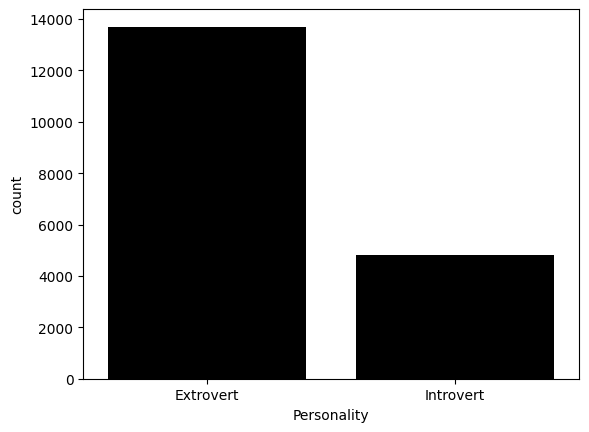

In [13]:
sns.countplot(x=target, color='black')
plt.show()

## Univariate Analysis

####  Categorical Columns

Value counts for Stage_fear
Stage_fear
No     12609
Yes     4022
Name: count, dtype: int64


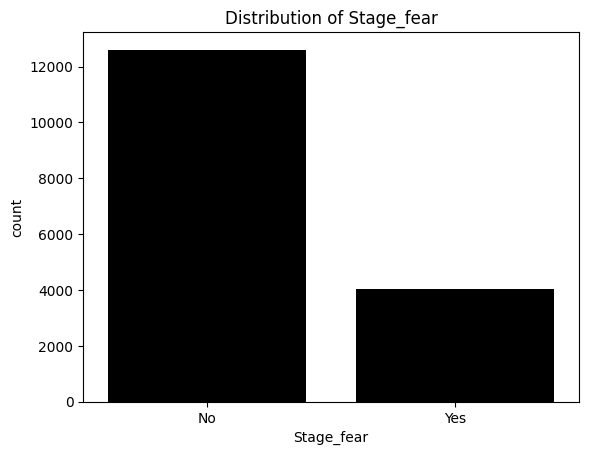

Value counts for Drained_after_socializing
Drained_after_socializing
No     13313
Yes     4062
Name: count, dtype: int64


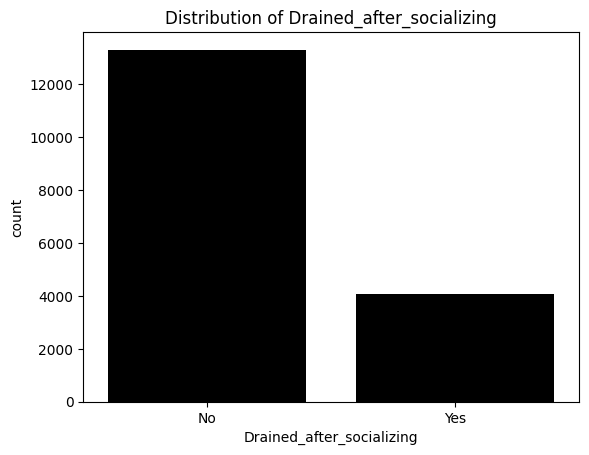

In [14]:
cat_cols = ['Stage_fear', 'Drained_after_socializing']

for col in cat_cols:
    
    print(f"Value counts for {col}")
    print(train[col].value_counts())
    
    sns.countplot(x=train[col], color='black')
    plt.title(f"Distribution of {col}")
    plt.show()

#### Numeric Columns

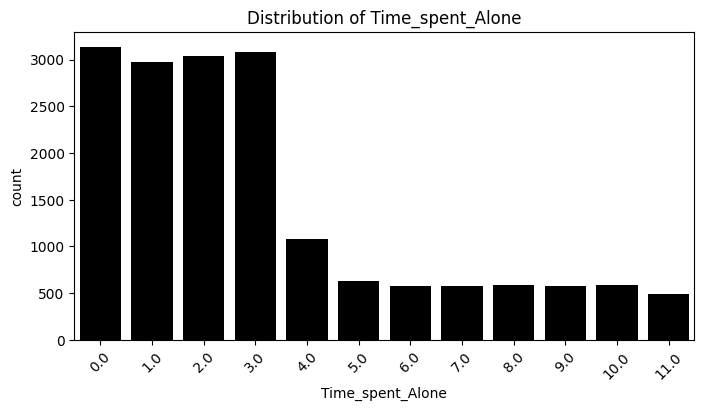

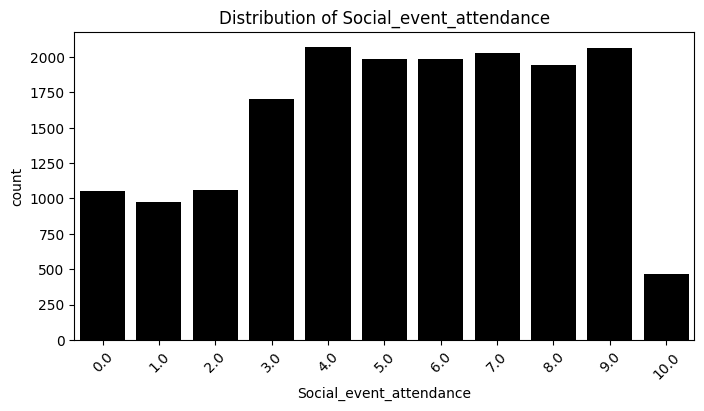

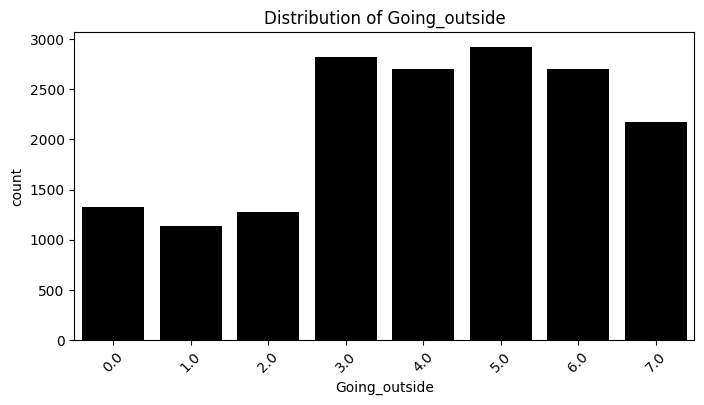

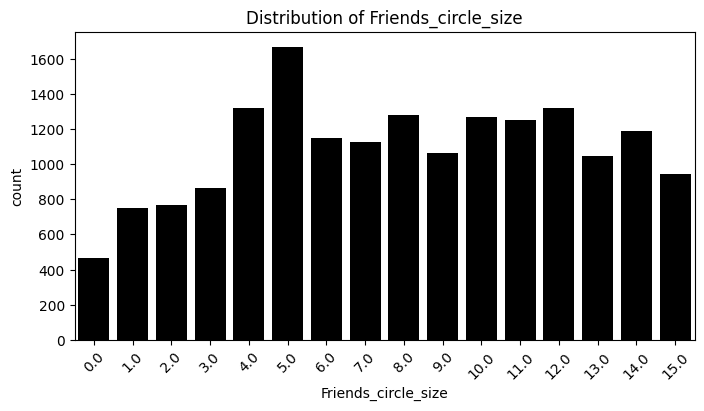

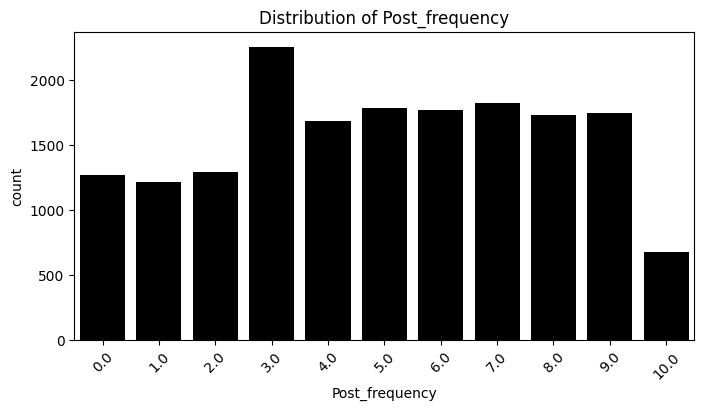

In [15]:
num_cols = train.select_dtypes(include=['number']).columns

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=train[col], color='black')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

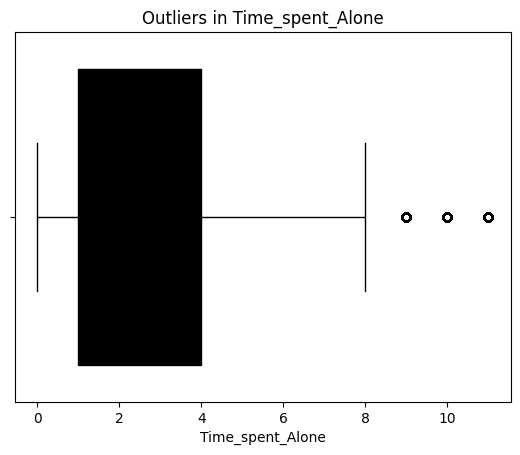

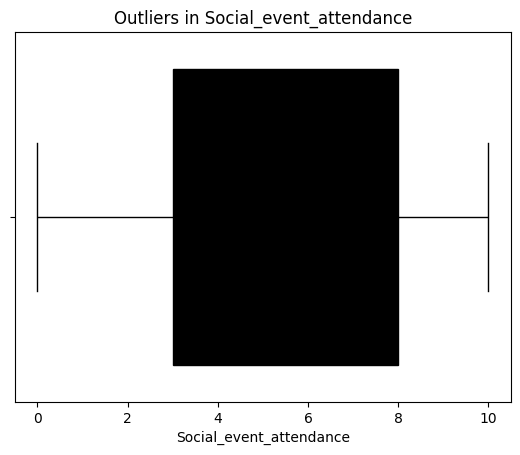

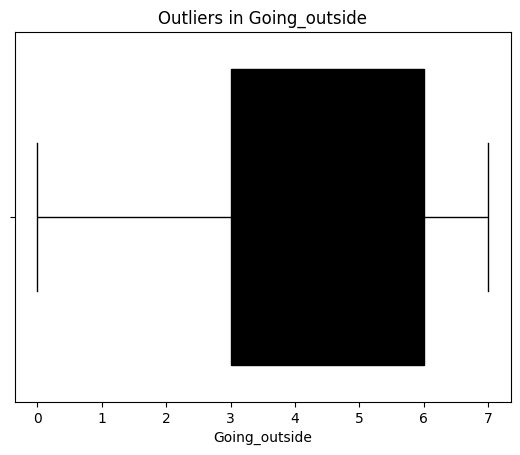

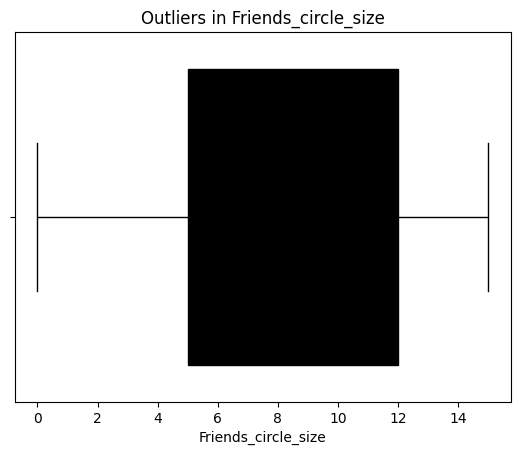

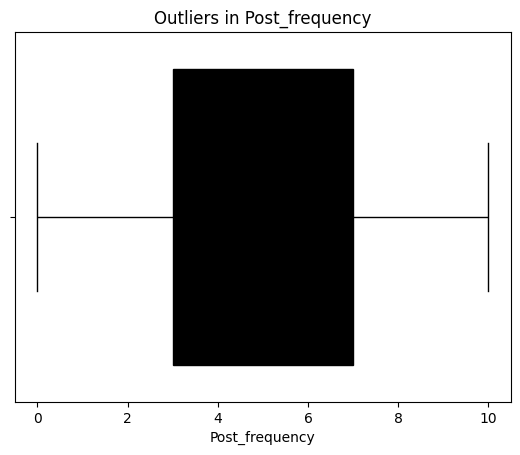

In [16]:
for col in num_cols:
    
    sns.boxplot(x=train[col], color='black')
    plt.title(f"Outliers in {col}")
    plt.show()

## Bivariate Analysis

#### Categorical vs Target

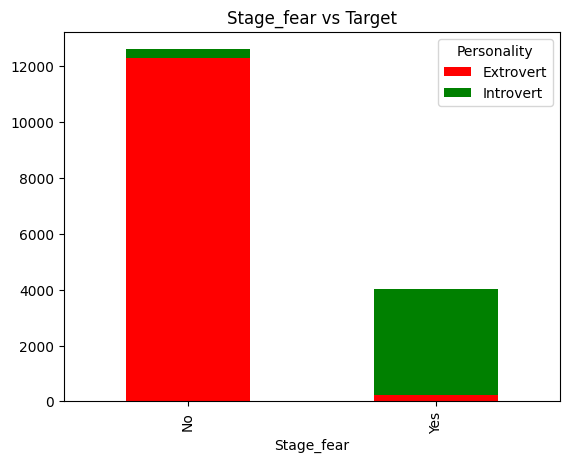

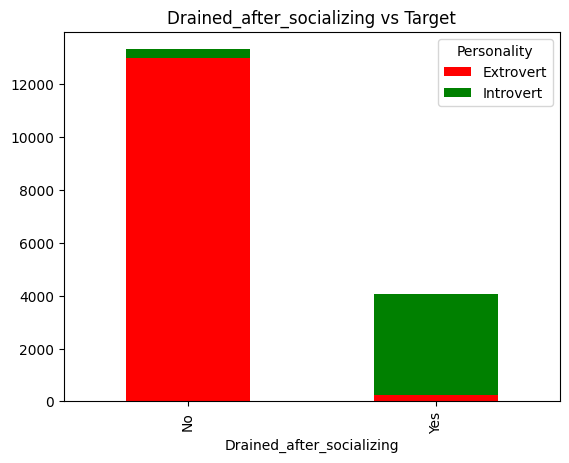

In [17]:
color = ['red', 'green']
for col in cat_cols:
    
    pd.crosstab(train[col], target).plot(kind='bar', stacked=True, color=color)

    plt.title(f"{col} vs Target")
    plt.show()

#### Numeric vs Target

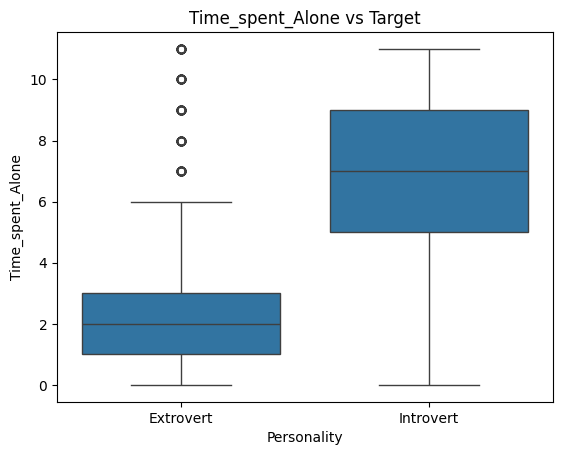

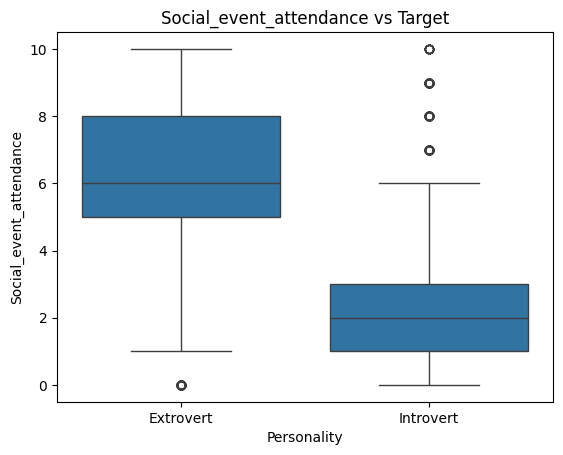

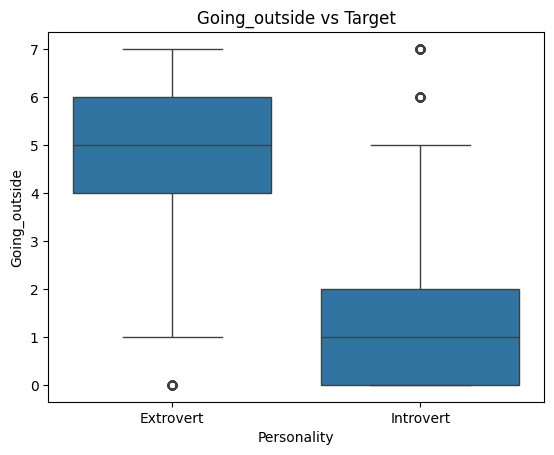

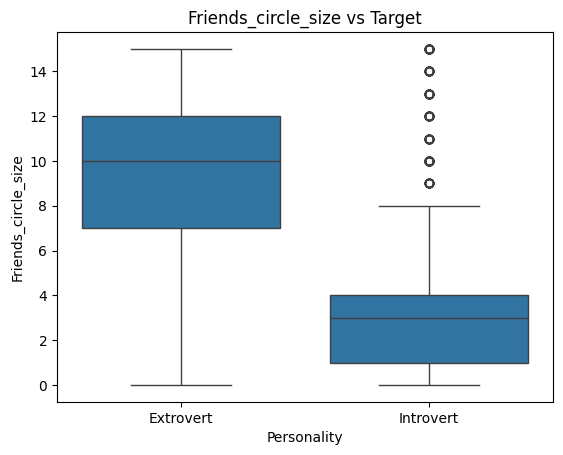

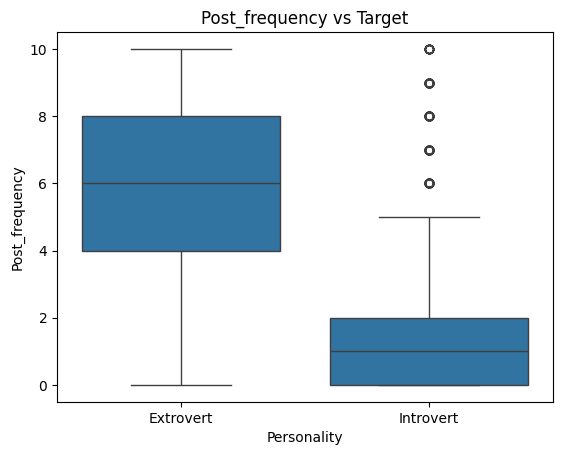

In [18]:
for col in num_cols:
    
    sns.boxplot(x=target, y=train[col])
    plt.title(f"{col} vs Target")
    plt.show()

## Multivariate Analysis

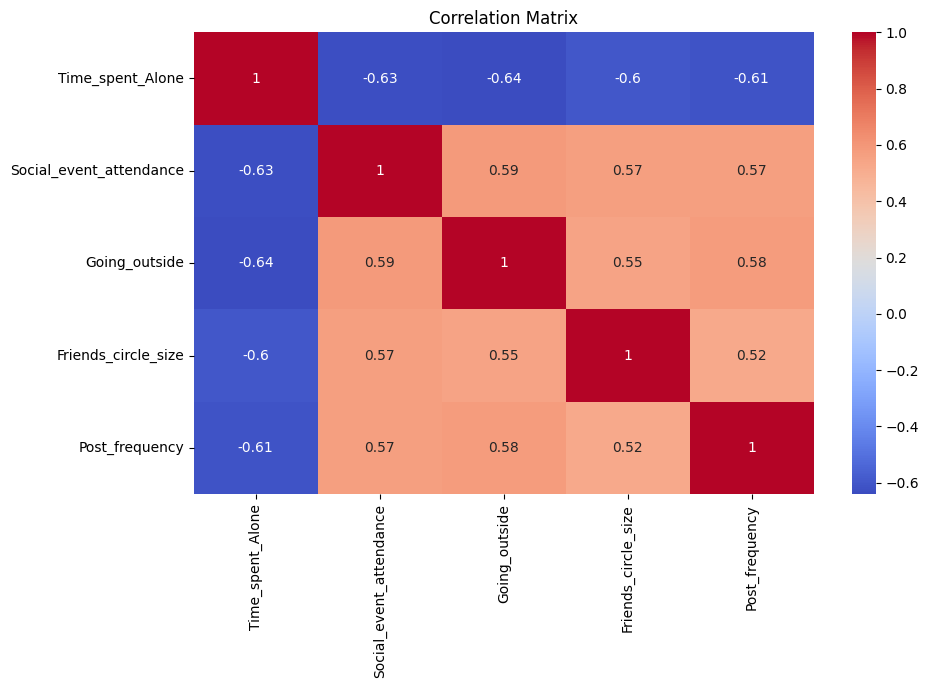

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(train[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

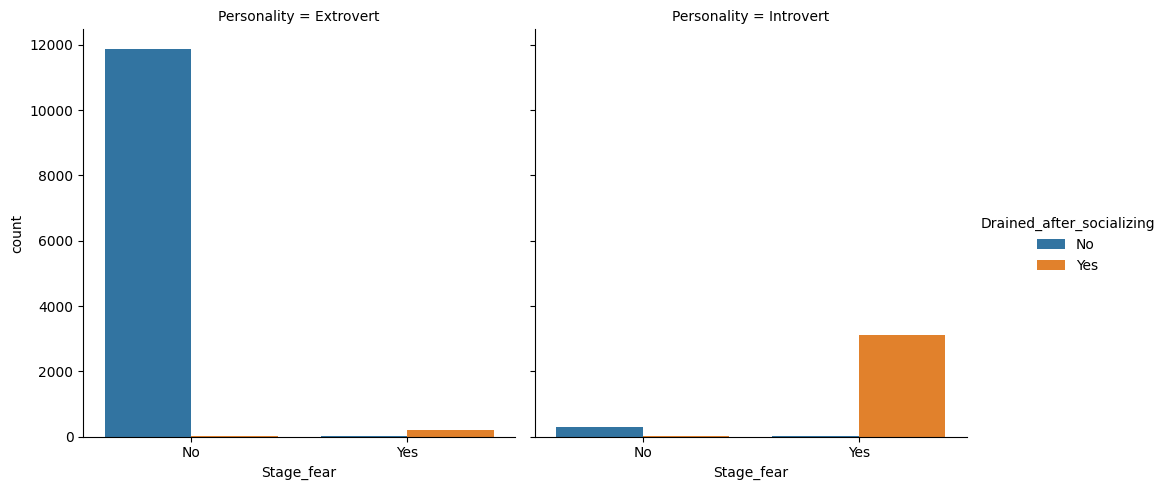

In [20]:
sns.catplot(
    x='Stage_fear',
    hue='Drained_after_socializing',
    col=target,
    kind='count',
    data=train
)
# plt.ylim(0, 1000) 
plt.show()

# 4. Preprocessing

In [21]:
num_cols = train.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = train[(train[col] < lower) | (train[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

Time_spent_Alone: 1653 outliers
Social_event_attendance: 0 outliers
Going_outside: 0 outliers
Friends_circle_size: 0 outliers
Post_frequency: 0 outliers


In [22]:
train['Time_spent_Alone'] = train['Time_spent_Alone'].clip(lower, upper)

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_columns_mean = ['Social_event_attendance', 'Going_outside', 'Friends_circle_size',
                  'Post_frequency']
num_columns_median = ['Time_spent_Alone']
cat_columns = ['Stage_fear', 'Drained_after_socializing']

num_pipeline_mean = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

num_pipeline_median = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessing = ColumnTransformer([
    ('num_mean', num_pipeline_mean, num_columns_mean),
    ('num_median', num_pipeline_median, num_columns_median), 
    ('cat', cat_pipeline, cat_columns)
])

# 5. Model Selection

Base Model Evaluation on :


- Logistic Regression
  
- Decision Tree

- Random Forest

- Ada Boost

- Gradient Boost

- XG Boost

In [24]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

train = pd.read_csv('/kaggle/input/competitions/playground-series-s5e7/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s5e7/test.csv')

train['Personality'] = train['Personality'].map({'Extrovert':1,'Introvert':0})

y = train['Personality']
x = train.drop(columns=['Personality','id'])

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = []

for name in models:

    print("Training Model:", name)

    model = Pipeline([
        ('preprocessing', preprocessing),
        ('model', models[name])
    ])

    model.fit(x_train, y_train)

    y_train_proba = model.predict_proba(x_train)[:,1]
    y_test_proba = model.predict_proba(x_test)[:,1]

    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)

    results.append({
        "Model": name,
        "Train ROC-AUC": train_auc,
        "Test ROC-AUC": test_auc
    })

results_df = pd.DataFrame(results)

print(results_df)

Training Model: LogisticRegression
Training Model: DecisionTree
Training Model: RandomForest
Training Model: GradientBoost
Training Model: AdaBoost
Training Model: XGBoost
                Model  Train ROC-AUC  Test ROC-AUC
0  LogisticRegression       0.959926      0.945862
1        DecisionTree       0.999977      0.907212
2        RandomForest       0.999949      0.955059
3       GradientBoost       0.978427      0.962621
4            AdaBoost       0.972380      0.960439
5             XGBoost       0.996934      0.956291


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:18:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Several models were evaluated using Train ROC-AUC and Test ROC-AUC scores, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, and XGBoost.

Logistic Regression showed stable performance with a small gap between train and test scores. Decision Tree showed clear overfitting with a very high training score and lower test performance. Random Forest and XGBoost performed well but showed slight overfitting due to higher training scores. AdaBoost demonstrated strong and stable performance.

Among all models, Gradient Boosting achieved the highest Test ROC-AUC score, making it the best performing model. Therefore, Gradient Boosting was selected as the final model.

# 6. Feature Selection

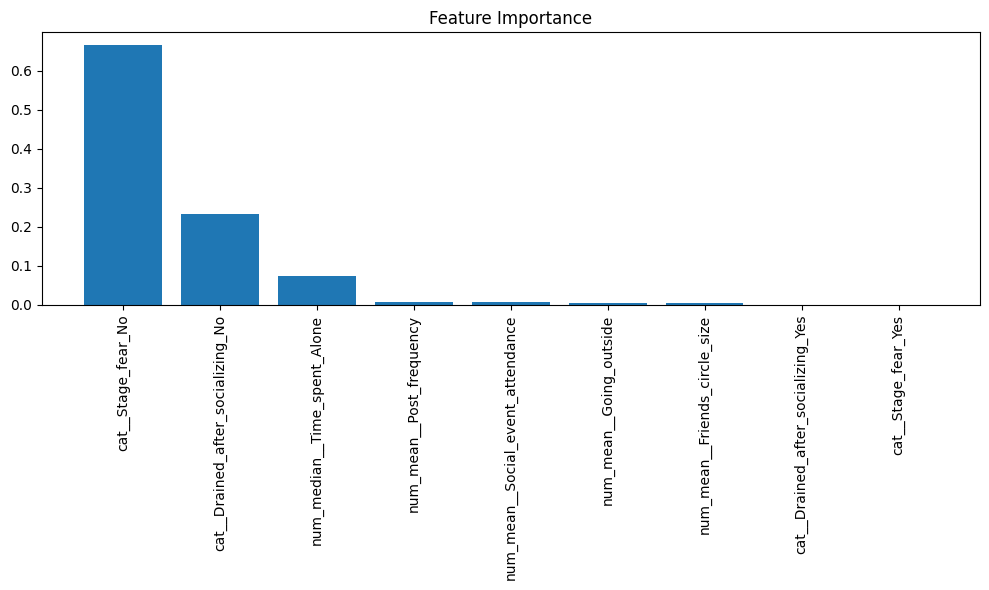

In [25]:
final_model = model.named_steps['model']

feature_names = model.named_steps['preprocessing'].get_feature_names_out()

importance_score = final_model.feature_importances_

indices = np.argsort(importance_score)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance")

plt.bar(range(len(feature_names)), importance_score[indices])

plt.xticks(range(len(feature_names)), feature_names[indices], rotation=90)

plt.tight_layout()
plt.show()

Feature importance from the Gradient Boosting model was analyzed to identify which variables contribute most to the prediction. The analysis shows that Stage_fear, Drained_after_socializing, and Time_spent_Alone are the most influential features. Other features have relatively low importance.

# 7. Hyperparameter Tuning

In [26]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

train = pd.read_csv('/kaggle/input/competitions/playground-series-s5e7/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s5e7/test.csv')

train['Personality'] = train['Personality'].map({'Extrovert':1,'Introvert':0})

y = train['Personality']
x = train.drop(columns=['Personality','id'])

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

num_columns_median = ['Time_spent_Alone']

cat_columns = ['Stage_fear', 'Drained_after_socializing']

num_pipeline_mean = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

num_pipeline_median = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessing = ColumnTransformer([
    ('num_mean', num_pipeline_mean, num_columns_mean),
    ('num_median', num_pipeline_median, num_columns_median), 
    ('cat', cat_pipeline, cat_columns)
])

params = {
    'max_depth': [6,8],
    'min_samples_split':[5,10],
    'learning_rate': [0.05], 
    'n_estimators': [500]
}

cv_model = GridSearchCV(
    GradientBoostingClassifier(),
    params,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring = 'roc_auc',
    n_jobs = -1,
    verbose = 1,
)

model = Pipeline([
    ('preprocessing', preprocessing),
    ('model', cv_model)
])

model.fit(x_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_mean',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('num_median',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Time_spe...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('model',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                              estimator=GradientBoostingClassifier(), n_jobs=-1,
                              param_grid={'learning_rate': [0.05],
                                          'max_depth': [6, 8],
                                          'min_samples_split': [5, 10],
                                          'n_estimators': [500]},
                              scoring='roc_auc', verbose=1))])

# 8. Evaluation

In [27]:
from sklearn.metrics import roc_auc_score

y_train_proba = model.predict_proba(x_train)[:, 1]
y_test_proba = model.predict_proba(x_test)[:, 1]

train_score = roc_auc_score(y_train, y_train_proba)
test_score = roc_auc_score(y_test, y_test_proba)

print("Train ROC-AUC:", train_score)
print("Test ROC-AUC :", test_score)

Train ROC-AUC: 0.9973725852508898
Test ROC-AUC : 0.9571109174323031


# 9. Refit Test Data

In [28]:
pred = model.predict(test.drop(columns=['id']))

pred = pd.Series(pred).map({0: 'Introvert', 1: 'Extrovert'})

submission = pd.DataFrame({
    'id': test['id'],
    'Personality': pred
})

submission.to_csv('submission.csv', index=False)

In [29]:
print(submission.head())
print(submission['Personality'].unique())

      id Personality
0  18524   Extrovert
1  18525   Introvert
2  18526   Extrovert
3  18527   Extrovert
4  18528   Introvert
['Extrovert' 'Introvert']


# 10. Conclusion

In this notebook, we built a machine learning model to predict personality type (Extrovert vs Introvert) using the Kaggle Playground Series S5E7 dataset.

A Gradient Boosting Classifier was used along with a preprocessing pipeline to handle missing values, scaling, and categorical encoding.

GridSearchCV with Stratified K-Fold cross-validation was applied to tune key hyperparameters such as max_depth, min_samples_split, learning_rate, and n_estimators.

The model was evaluated using the ROC–AUC metric, and the trained pipeline was used to generate predictions for Kaggle submission.